# ✈️ Aviation Operational Performance Analysis — January 2025

## 📌 Project Objective

This project analyzes U.S. aviation flight operations for January 2025 to identify:

- Flight volume and operational scale
- Delay and cancellation performance
- Airline reliability
- Airport and route performance
- Major causes of flight delays
- Operational efficiency opportunities

## 🛠 Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 📊 Analysis Workflow

1. Import libraries
2. Load dataset
3. Inspect dataset
4. Check data quality
5. Prepare data
6. Exploratory data analysis
7. Business insights
8. Recommendations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


In [2]:
# LOADING DATA
df=pd.read_csv('aviation_cleaned_JAN2025.csv',low_memory=False)
df.head(1)

,Year,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,DOT_ID_Reporting_Airline,IATA_CODE_Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,OriginAirportID,...,DivActualElapsedTime,DivArrDelay,DivDistance,Div1Airport,Div1TailNum,IsDelayed,IsDelayed15,IsCancelled,IsDiverted,IsSeverelyDelayed
0,2025,1,3,01-01-2025,AA,19805,AA,N104NN,1,12478,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0


In [3]:
df.shape

(487346, 73)

## DATASET OVERVIEW
Each row represents an individual scheduled flight and contains information about:

- Airline
- Origin and destination
- Scheduled and actual departure/arrival times
- Delays
- Cancellation/diversion status
- Distance
- Delay causes

In [4]:
df.columns.tolist()

['Year',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'DOT_ID_Reporting_Airline',
 'IATA_CODE_Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CRSElapsedTime',
 'ActualElapsedTime',
 'AirTime',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityDelay',
 'LateAircraftDelay',
 'Fir

##  Key Business Columns

### Flight Identification
- FlightDate → Date of flight
- Reporting_Airline → Airline code
- Flight_Number_Reporting_Airline → Flight number

### Route Information
- Origin → Origin airport
- Dest → Destination airport
- OriginCityName → Origin city
- DestCityName → Destination city
- Distance → Flight distance

### Departure Performance
- CRSDepTime → Scheduled departure time
- DepTime → Actual departure time
- DepDelay → Departure delay in minutes
- DepDel15 → Whether departure was delayed by 15+ minutes

### Arrival Performance
- CRSArrTime → Scheduled arrival time
- ArrTime → Actual arrival time
- ArrDelay → Arrival delay in minutes
- ArrDel15 → Whether arrival was delayed by 15+ minutes

### Operational Status
- Cancelled → Cancellation indicator
- Diverted → Diversion indicator
- IsDelayed → Delay indicator
- IsDelayed15 → 15+ minute delay indicator
- IsCancelled → Cancellation indicator
- IsDiverted → Diversion indicator
- IsSeverelyDelayed → Severe delay indicator

### Delay Causes
- CarrierDelay
- WeatherDelay
- NASDelay
- SecurityDelay
- LateAircraftDelay

In [5]:
# check datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487346 entries, 0 to 487345
Data columns (total 73 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Year                             487346 non-null  int64  
 1   DayofMonth                       487346 non-null  int64  
 2   DayOfWeek                        487346 non-null  int64  
 3   FlightDate                       487346 non-null  object 
 4   Reporting_Airline                487346 non-null  object 
 5   DOT_ID_Reporting_Airline         487346 non-null  int64  
 6   IATA_CODE_Reporting_Airline      487346 non-null  object 
 7   Tail_Number                      485021 non-null  object 
 8   Flight_Number_Reporting_Airline  487346 non-null  int64  
 9   OriginAirportID                  487346 non-null  int64  
 10  OriginAirportSeqID               487346 non-null  int64  
 11  OriginCityMarketID               487346 non-null  int64  
 12  Or

In [6]:
# FLIGHT DATE IS OBJECT CONVERT IT INTO date and time
df['FlightDate']=pd.to_datetime(
    df['FlightDate'],
     format="%d-%m-%Y"
)
print(df["FlightDate"].dtype)
df["FlightDate"].head()

datetime64[ns]


0   2025-01-01
1   2025-01-02
2   2025-01-03
3   2025-01-04
4   2025-01-05
Name: FlightDate, dtype: datetime64[ns]

In [7]:
# BASIC INSPECTION DATASET MATRICS
total_rows = df.shape[0]
total_columns = df.shape[1]
duplicate_rows = df.duplicated().sum()
missing_values = df.isnull().sum().sum()

overview = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Total Missing Values"
    ],
    "Value": [
        total_rows,
        total_columns,
        duplicate_rows,
        missing_values
    ]
})

display(overview)

,Metric,Value
0,Total Rows,487346
1,Total Columns,73
2,Duplicate Rows,0
3,Total Missing Values,7073606


In [8]:
# NULL VALUE
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing = missing[
    missing["Missing Values"] > 0
].sort_values(
    "Missing %",
    ascending=False
)

display(missing)

,Missing Values,Missing %
Div1TailNum,486499,99.83
DivArrDelay,486517,99.83
DivActualElapsedTime,486517,99.83
DivDistance,486269,99.78
DivReachedDest,486269,99.78
Div1Airport,486189,99.76
LongestAddGTime,483404,99.19
TotalAddGTime,483404,99.19
FirstDepTime,483404,99.19
CancellationCode,472836,97.02


In [9]:
# UNIQUE AIRLINES
df["Reporting_Airline"].nunique()

12

In [10]:
# CREATE ENITRE ROUTE
df["Route"] = (
    df["Origin"] +
    " → " +
    df["Dest"]
)


# Insight 1 — Aviation Operational Overview
- OVERALL SCALE AND OPERATIONAL STATUS OF AVIATION SECTOR

In [11]:
# TOTAL FLIGHT
total_flights=len(df)
total_flights

487346

In [12]:
total_airlines=df['Reporting_Airline'].nunique()
total_airlines

12

In [13]:
# TOTAL AIRPORTS USING SET FOR DISTINCT VALUES AND UNION 
total_airports= len(set(df["Origin"]).union(set(df["Dest"])))
total_airports

318

In [14]:
#total routes
total_routes=df['Route'].nunique()
total_routes

5434

In [15]:
# TOTAL CANCELLED FLIGHTS
cancelled_flights=df['IsCancelled'].sum()
cancelled_flights

np.int64(14510)

In [16]:
# Cancellation Rate
cancellation_rate = (
    cancelled_flights / total_flights
) * 100

print(
    f"Cancellation Rate: {cancellation_rate:.2f}%"
)

Cancellation Rate: 2.98%


In [17]:
# DIVERTED FLIGHTS
diverted_flights = df["IsDiverted"].sum()

diversion_rate = (
    diverted_flights / total_flights
) * 100
print(f"Diverted Flights: {diverted_flights:,}")
print(f"Diversion Rate: {diversion_rate:.2f}%")

Diverted Flights: 1,077
Diversion Rate: 0.22%


In [18]:
# DELAYED FLIGHTS
delayed_15_flights = df["IsDelayed15"].sum()

delay_15_rate = (
    delayed_15_flights / total_flights
) * 100
print(f"15+ Minute Delays: {delayed_15_flights:,}")
print(f"15+ Minute Delay Rate: {delay_15_rate:.2f}%")

15+ Minute Delays: 88,830
15+ Minute Delay Rate: 18.23%


In [19]:
# WAY TOO DELAY'
delayed_flight=df['IsSeverelyDelayed'].sum()
delayed_flight_rate=(
    delayed_flight/total_flights
)*100
print(f'Delayed Flights: {delayed_flight:,} ')
print(f'Delayed Flights: {delayed_flight_rate:,.2f}% ')

Delayed Flights: 30,104 
Delayed Flights: 6.18% 


In [20]:
# OVERALL METRICS SUMMARY
overview_metrics = pd.DataFrame({
    "Metric": [
        "Total Flights",
        "Airlines",
        "Airports",
        "Routes",
        "15+ Min Delayed Flights",
        "15+ Min Delay Rate",
        "Cancelled Flights",
        "Cancellation Rate",
        "Diverted Flights",
        "Diversion Rate",
        "Severely Delayed Flights",
        "Severe Delay Rate"
    ],
    
    "Value": [
        f"{total_flights:,}",
        f"{total_airlines:,}",
        f"{total_airports:,}",
        f"{total_routes:,}",
        f"{delayed_15_flights:,}",
        f"{delay_15_rate:.2f}%",
        f"{cancelled_flights:,}",
        f"{cancellation_rate:.2f}%",
        f"{diverted_flights:,}",
        f"{diversion_rate:.2f}%",
        f"{delayed_flight:,}",
        f"{delayed_flight_rate:.2f}%"
    ]
})

display(overview_metrics)

,Metric,Value
0,Total Flights,"487,346"
1,Airlines,12
2,Airports,318
3,Routes,"5,434"
4,15+ Min Delayed Flights,"88,830"
5,15+ Min Delay Rate,18.23%
6,Cancelled Flights,"14,510"
7,Cancellation Rate,2.98%
8,Diverted Flights,"1,077"
9,Diversion Rate,0.22%


In [21]:
# FLIGHT OPERATIONAL STATUS == DISRUPTION
status_counts = pd.Series({
    "15+ Min Delayed": delayed_15_flights,
    "Cancelled": cancelled_flights,
    "Diverted": diverted_flights,
    "Severe Delay": delayed_flight
})

status_counts

15+ Min Delayed    88830
Cancelled          14510
Diverted            1077
Severe Delay       30104
dtype: int64

## VISUALISATION OF OPERATIONAL STATUS

C:\Users\rishu\AppData\Local\Temp\ipykernel_12004\487768753.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


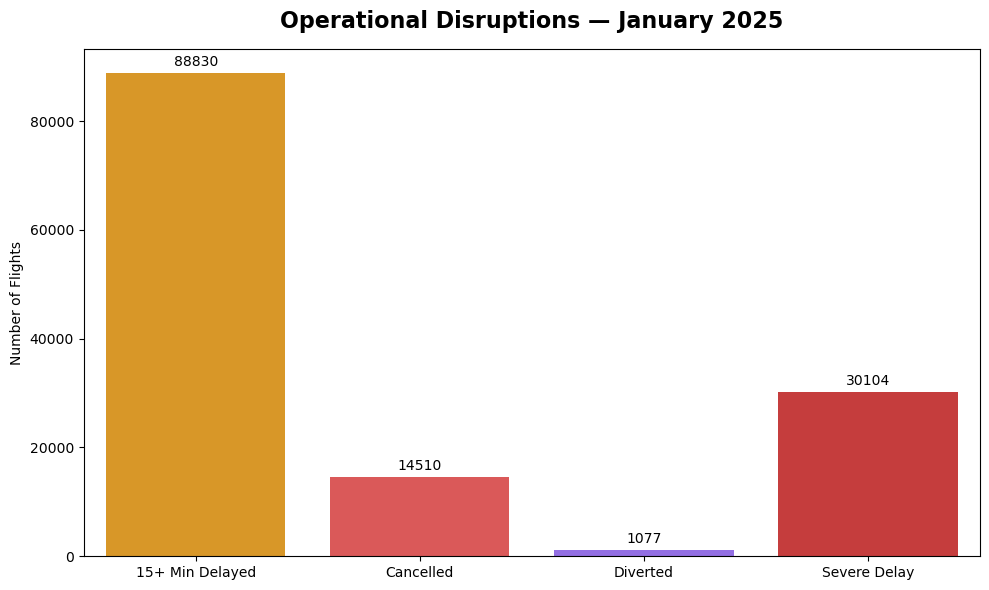

In [22]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    palette=["#F59E0B", "#EF4444", "#8B5CF6", "#DC2626"]
)

plt.title(
    "Operational Disruptions — January 2025",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("")
plt.ylabel("Number of Flights")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.tight_layout()
plt.show()

###  Business Interpretation

The January,2025 aviation dataset contains approximately 487K scheduled flight records across multiple airlines, airports, and routes.

The operational overview establishes the baseline for subsequent reliability analysis by measuring:

- The proportion of flights experiencing 15+ minute delays
- Cancellation frequency
- Diversion frequency
- Severe delay frequency

Rather than relying only on raw disruption counts, rates are used to normalize performance against total flight volume.

The next stage of analysis will determine which airlines, airports, routes, and time periods contribute most strongly to these operational disruptions.

# INSIGHT 2 — Airline Delay Performance
-  airlines that have the highest and lowest rates of flights delayed by 15 minutes or more

In [23]:
# TOTAL FLIGHTS BY AIRRLINE
airline_flights=df.groupby('Reporting_Airline').size().reset_index(name='total_flights')
display(airline_flights)

,Reporting_Airline,total_flights
0,AA,75088
1,AS,18163
2,B6,17918
3,DL,76306
4,F9,15526
5,G4,2556
6,NK,512
7,OH,21094
8,OO,65036
9,UA,62007


In [24]:
# TOTAL DELAYED FLIGHTS
airline_delayed=df.groupby("Reporting_Airline")['IsDelayed15'].sum().reset_index(name='Delayed 15')
display(airline_delayed)

,Reporting_Airline,Delayed 15
0,AA,13860
1,AS,3137
2,B6,4294
3,DL,14302
4,F9,3925
5,G4,567
6,NK,105
7,OH,4880
8,OO,13261
9,UA,10694


In [25]:
airline_performance=airline_flights.merge(
    airline_delayed,
    on="Reporting_Airline"
)
display(airline_performance)

,Reporting_Airline,total_flights,Delayed 15
0,AA,75088,13860
1,AS,18163,3137
2,B6,17918,4294
3,DL,76306,14302
4,F9,15526,3925
5,G4,2556,567
6,NK,512,105
7,OH,21094,4880
8,OO,65036,13261
9,UA,62007,10694


In [26]:
# CORRECTED CODE
airline_performance["Delay_Rate"] = (
    airline_performance["Delayed 15"]
    / airline_performance["total_flights"]
    * 100
)

airline_performance["Delay_Rate"] = (
    airline_performance["Delay_Rate"].round(2)
)

display(airline_performance)

,Reporting_Airline,total_flights,Delayed 15,Delay_Rate
0,AA,75088,13860,18.46
1,AS,18163,3137,17.27
2,B6,17918,4294,23.96
3,DL,76306,14302,18.74
4,F9,15526,3925,25.28
5,G4,2556,567,22.18
6,NK,512,105,20.51
7,OH,21094,4880,23.13
8,OO,65036,13261,20.39
9,UA,62007,10694,17.25


In [27]:
airline_delay_ranking = (
    airline_performance
    .sort_values("Delay_Rate", ascending=False)
)

display(airline_delay_ranking)

,Reporting_Airline,total_flights,Delayed 15,Delay_Rate
4,F9,15526,3925,25.28
2,B6,17918,4294,23.96
7,OH,21094,4880,23.13
5,G4,2556,567,22.18
6,NK,512,105,20.51
8,OO,65036,13261,20.39
3,DL,76306,14302,18.74
0,AA,75088,13860,18.46
1,AS,18163,3137,17.27
9,UA,62007,10694,17.25


In [28]:
worst_airline=airline_delay_ranking.iloc[0]
print(
    f"Worst delay rate: "
    f"{worst_airline['Reporting_Airline']} "
    f"({worst_airline['Delay_Rate']:.2f}%)"
)

Worst delay rate: F9 (25.28%)


In [29]:
# Best airline in terms of delay
best_airline=airline_delay_ranking.iloc[-1]
print(
    f"best delay rate: "
    f"{best_airline['Reporting_Airline']} "
    f"({best_airline['Delay_Rate']:.2f}%)"
)

best delay rate: WN (14.75%)


## VISUALISATION OF ABOVE INSIGHT

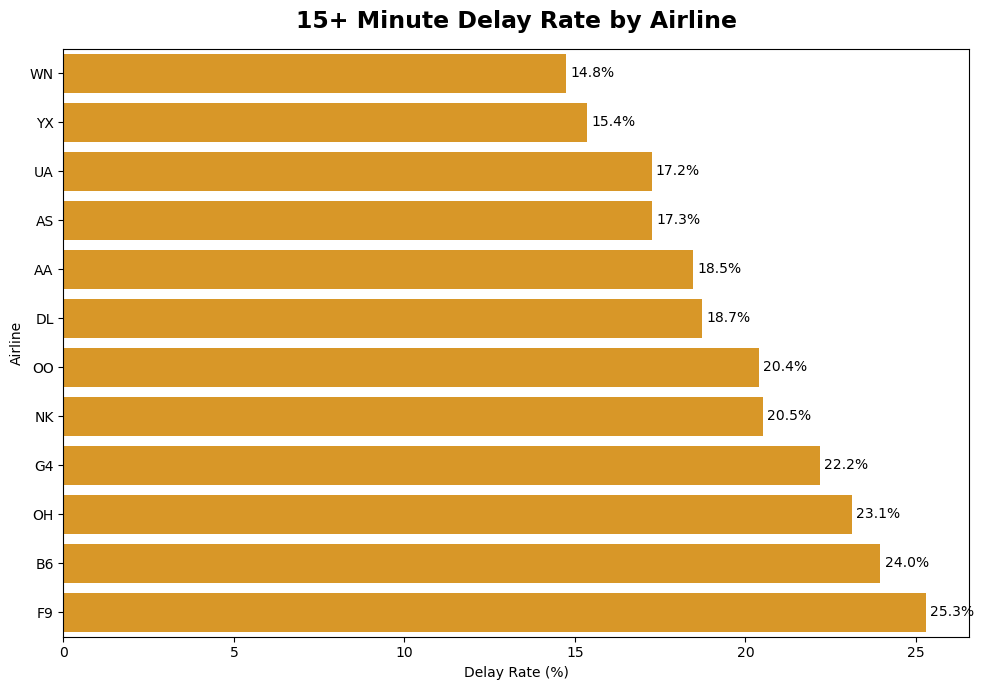

In [30]:
plt.figure(figsize=(10, 7))

plot_data = airline_delay_ranking.sort_values(
    "Delay_Rate",
    ascending=True
)

ax = sns.barplot(
    data=plot_data,
    x="Delay_Rate",
    y="Reporting_Airline",
    color="#F59E0B"
)

plt.title(
    "15+ Minute Delay Rate by Airline",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Airline")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

# BUSSINESS INSIGHT
###  Key Finding
Airline **[F9]** has the highest 15+ minute delay rate at **[25.29%]%**, while **[WN]** has the lowest rate at **[14.75]%**.


# Insight 3 — Airline Cancellation Performance
-  Which airlines have the highest and lowest flight cancellation rates
-  **Cancellation Rate = Cancelled Flights / Total Flights × 100**

In [31]:
df['IsCancelled'].value_counts()
# 0 == NOT CANCELLED 
# 1 == CANCELLED

IsCancelled
0    472836
1     14510
Name: count, dtype: int64

In [32]:
# CANCELLATIONS BY AIRLINE
airline_cancellation= df.groupby('Reporting_Airline')['IsCancelled'].sum().reset_index(name='Cancelled_Flights')
display(airline_cancellation)

,Reporting_Airline,Cancelled_Flights
0,AA,2802
1,AS,243
2,B6,323
3,DL,2137
4,F9,392
5,G4,32
6,NK,15
7,OH,1899
8,OO,1343
9,UA,1189


In [33]:
# TOTAL FLIGHTS
airline_total_flights = (
    df.groupby("Reporting_Airline")
      .size()
      .reset_index(name="Total_Flights")
)

display(airline_total_flights)

,Reporting_Airline,Total_Flights
0,AA,75088
1,AS,18163
2,B6,17918
3,DL,76306
4,F9,15526
5,G4,2556
6,NK,512
7,OH,21094
8,OO,65036
9,UA,62007


In [34]:
# MERGE TABLES BASED ON REPOTING AIRLINES
cancellation_analysis=airline_total_flights.merge(
    airline_cancellation,
    on='Reporting_Airline'
)
display(cancellation_analysis)

,Reporting_Airline,Total_Flights,Cancelled_Flights
0,AA,75088,2802
1,AS,18163,243
2,B6,17918,323
3,DL,76306,2137
4,F9,15526,392
5,G4,2556,32
6,NK,512,15
7,OH,21094,1899
8,OO,65036,1343
9,UA,62007,1189


In [35]:
# CANCELLATION RATE
cancellation_analysis['Cancellation_Rate']=cancellation_analysis['Cancelled_Flights']/cancellation_analysis['Total_Flights']*100
# ROUNDING TO 2 decimals
cancellation_analysis['Cancellation_Rate']=(
    cancellation_analysis['Cancellation_Rate'].round(2)
)

display(cancellation_analysis)

,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate
0,AA,75088,2802,3.73
1,AS,18163,243,1.34
2,B6,17918,323,1.80
3,DL,76306,2137,2.80
4,F9,15526,392,2.52
5,G4,2556,32,1.25
6,NK,512,15,2.93
7,OH,21094,1899,9.00
8,OO,65036,1343,2.07
9,UA,62007,1189,1.92


## AIRLINES RANKING
- based on cancellation rate

In [36]:
cancellation_ranking=(
    cancellation_analysis.sort_values('Cancellation_Rate',ascending=True)
)
display(cancellation_ranking)

,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate
5,G4,2556,32,1.25
1,AS,18163,243,1.34
2,B6,17918,323,1.80
9,UA,62007,1189,1.92
8,OO,65036,1343,2.07
4,F9,15526,392,2.52
3,DL,76306,2137,2.80
10,WN,105307,3016,2.86
6,NK,512,15,2.93
0,AA,75088,2802,3.73


In [37]:
overall_cancellation_rate = (
    df["IsCancelled"].mean() * 100
)

print(
    f"Overall cancellation rate: "
    f"{overall_cancellation_rate:.2f}%"
)

Overall cancellation rate: 2.98%


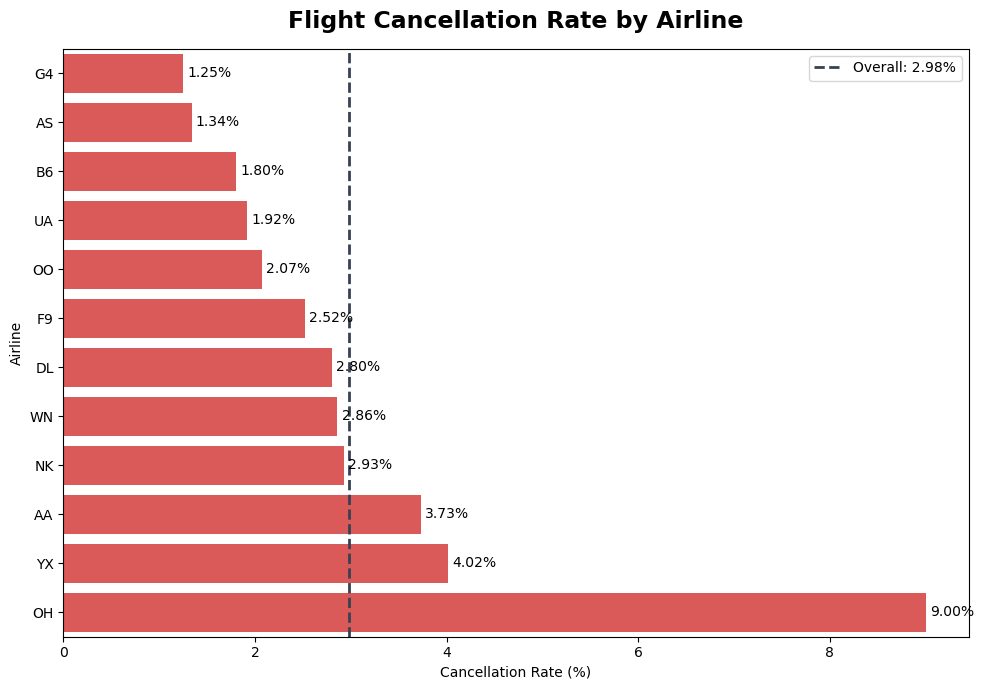

In [38]:
plt.figure(figsize=(10, 7))

plot_data = cancellation_ranking.sort_values(
    "Cancellation_Rate",
    ascending=True
)

ax = sns.barplot(
    data=plot_data,
    x="Cancellation_Rate",
    y="Reporting_Airline",
    color="#EF4444"
)

plt.axvline(
    overall_cancellation_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Overall: {overall_cancellation_rate:.2f}%"
)

plt.title(
    "Flight Cancellation Rate by Airline",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Airline")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.legend()

plt.tight_layout()
plt.show()

In [39]:
top_cancelled = cancellation_ranking.head(5)

bottom_cancelled = cancellation_ranking.tail(5)

print("🔴 Highest Cancellation Rates")
display(top_cancelled)

print("🟢 Lowest Cancellation Rates")
display(bottom_cancelled)

🔴 Highest Cancellation Rates


,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate
5,G4,2556,32,1.25
1,AS,18163,243,1.34
2,B6,17918,323,1.80
9,UA,62007,1189,1.92
8,OO,65036,1343,2.07


🟢 Lowest Cancellation Rates


,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate
10,WN,105307,3016,2.86
6,NK,512,15,2.93
0,AA,75088,2802,3.73
11,YX,27833,1119,4.02
7,OH,21094,1899,9.00


In [40]:
# BASED ON MIN FLIGHTS FOR EQUALITY
minimum_flights = 1000

cancellation_reliable_sample = (
    cancellation_analysis[
        cancellation_analysis["Total_Flights"] >= minimum_flights
    ]
    .sort_values(
        "Cancellation_Rate",
        ascending=False
    )
)

display(cancellation_reliable_sample)

,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate
7,OH,21094,1899,9.00
11,YX,27833,1119,4.02
0,AA,75088,2802,3.73
10,WN,105307,3016,2.86
3,DL,76306,2137,2.80
4,F9,15526,392,2.52
8,OO,65036,1343,2.07
9,UA,62007,1189,1.92
2,B6,17918,323,1.80
1,AS,18163,243,1.34


In [41]:
total_cancellations = (
    cancellation_analysis["Cancelled_Flights"].sum()
)

cancellation_analysis["Cancellation_Share"] = (
    cancellation_analysis["Cancelled_Flights"]
    / total_cancellations
    * 100
)

cancellation_analysis["Cancellation_Share"] = (
    cancellation_analysis["Cancellation_Share"].round(2)
)
display(
    cancellation_analysis.sort_values(
        "Cancellation_Share",
        ascending=False
    )
)

,Reporting_Airline,Total_Flights,Cancelled_Flights,Cancellation_Rate,Cancellation_Share
10,WN,105307,3016,2.86,20.79
0,AA,75088,2802,3.73,19.31
3,DL,76306,2137,2.80,14.73
7,OH,21094,1899,9.00,13.09
8,OO,65036,1343,2.07,9.26
9,UA,62007,1189,1.92,8.19
11,YX,27833,1119,4.02,7.71
4,F9,15526,392,2.52,2.70
2,B6,17918,323,1.80,2.23
1,AS,18163,243,1.34,1.67


# BUSSINESS INSIGHT
###  Key Finding
Airline **[OH]** recorded the highest cancellation rate at **[9]%**, while **[G4]** recorded the lowest rate at **[1.25]%**.


# INSIGHT 4 — Airport Cancellation Performance
-  Which airports have the highest cancellation rates

In [42]:
airport_flights=df.groupby('Origin').size().reset_index(name='Total_Flights')
display(airport_flights.head())

,Origin,Total_Flights
0,ABE,135
1,ABQ,1705
2,ABR,61
3,ABY,74
4,ACT,93


In [43]:
airport_cancellation=df.groupby('Origin')['IsCancelled'].sum().reset_index(name='Cancelled_Flight')
display(airline_cancellation)

,Reporting_Airline,Cancelled_Flights
0,AA,2802
1,AS,243
2,B6,323
3,DL,2137
4,F9,392
5,G4,32
6,NK,15
7,OH,1899
8,OO,1343
9,UA,1189


In [44]:
airport_analysis=airport_flights.merge(
    airport_cancellation,
    on='Origin'
)
display(airport_analysis)

,Origin,Total_Flights,Cancelled_Flight
0,ABE,135,5
1,ABQ,1705,27
2,ABR,61,0
3,ABY,74,11
4,ACT,93,6
...,...,...,...
313,WRG,60,1
314,XNA,424,16
315,XWA,178,1
316,YAK,60,5


In [45]:
#  Cancellation Rate
airport_analysis["Cancellation_Rate"] = (
    airport_analysis["Cancelled_Flight"]
    / airport_analysis["Total_Flights"]
    * 100
)

airport_analysis["Cancellation_Rate"] = (
    airport_analysis["Cancellation_Rate"].round(2)
)

display(airport_analysis.head())

,Origin,Total_Flights,Cancelled_Flight,Cancellation_Rate
0,ABE,135,5,3.70
1,ABQ,1705,27,1.58
2,ABR,61,0,0.00
3,ABY,74,11,14.86
4,ACT,93,6,6.45


In [46]:
# Airport Ranking
airport_ranking_all=(
    airport_analysis.sort_values('Cancellation_Rate',ascending=False)
)
display(airport_analysis.head())

,Origin,Total_Flights,Cancelled_Flight,Cancellation_Rate
0,ABE,135,5,3.70
1,ABQ,1705,27,1.58
2,ABR,61,0,0.00
3,ABY,74,11,14.86
4,ACT,93,6,6.45


In [47]:
# WITH MIN 1000 flights
minimum_flights = 1000

airport_reliable_sample = (
    airport_analysis[
        airport_analysis["Total_Flights"] >= minimum_flights
    ]
    .sort_values(
        "Cancellation_Rate",
        ascending=False
    )
)

display(airport_reliable_sample.head(15))

,Origin,Total_Flights,Cancelled_Flight,Cancellation_Rate
260,SAV,1199,134,11.18
203,MSY,3576,362,10.12
56,CHS,1568,152,9.69
76,DCA,11329,1066,9.41
180,MCI,3303,277,8.39
289,STL,4565,320,7.01
80,DFW,19275,1214,6.30
132,HOU,3995,247,6.18
267,SDF,1603,93,5.80
140,IAH,8449,474,5.61


In [48]:
#  top 15 worst airports
top_15_cancel_airports = (
    airport_reliable_sample
    .head(15)
    .sort_values(
        "Cancellation_Rate",
        ascending=True
    )
)

display(top_15_cancel_airports)

,Origin,Total_Flights,Cancelled_Flight,Cancellation_Rate
62,CLT,16098,721,4.48
74,DAL,5755,294,5.11
15,ATL,23096,1184,5.13
14,ASE,1025,54,5.27
27,BHM,1021,54,5.29
140,IAH,8449,474,5.61
267,SDF,1603,93,5.80
132,HOU,3995,247,6.18
80,DFW,19275,1214,6.30
289,STL,4565,320,7.01


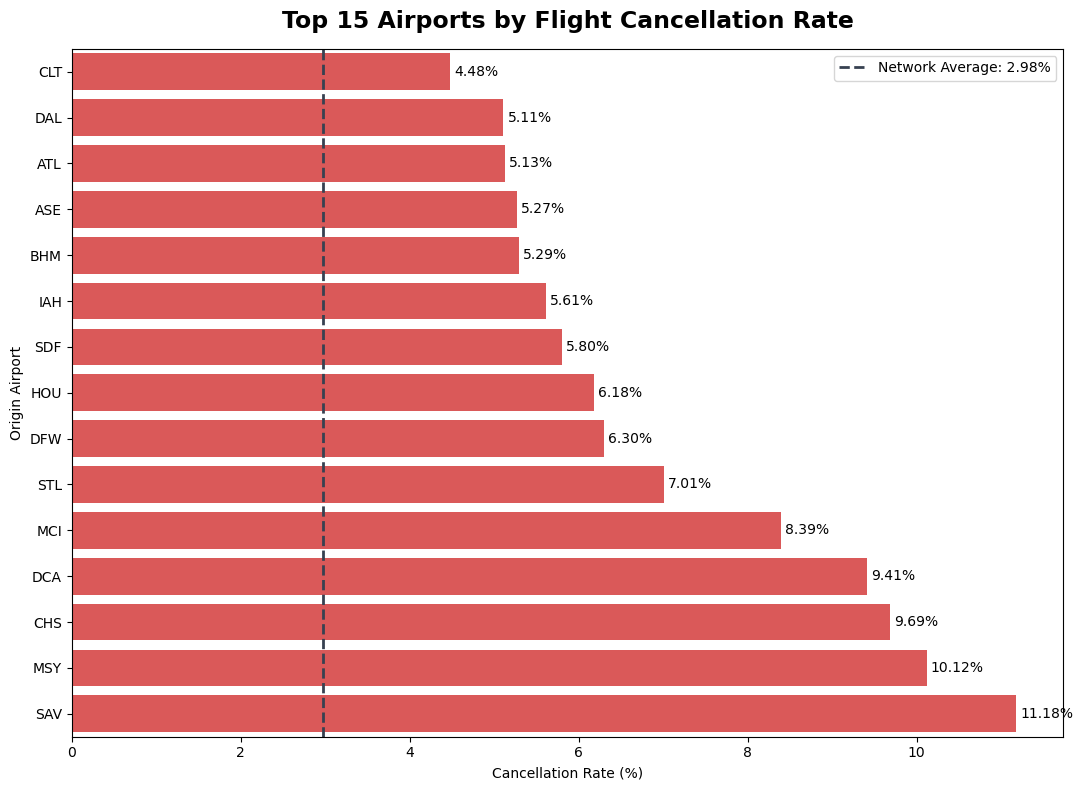

In [49]:
# Visualization
plt.figure(figsize=(11, 8))

ax = sns.barplot(
    data=top_15_cancel_airports,
    x="Cancellation_Rate",
    y="Origin",
    color="#EF4444"
)

plt.axvline(
    overall_cancellation_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Network Average: {overall_cancellation_rate:.2f}%"
)

plt.title(
    "Top 15 Airports by Flight Cancellation Rate",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Origin Airport")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.legend()

plt.tight_layout()
plt.show()


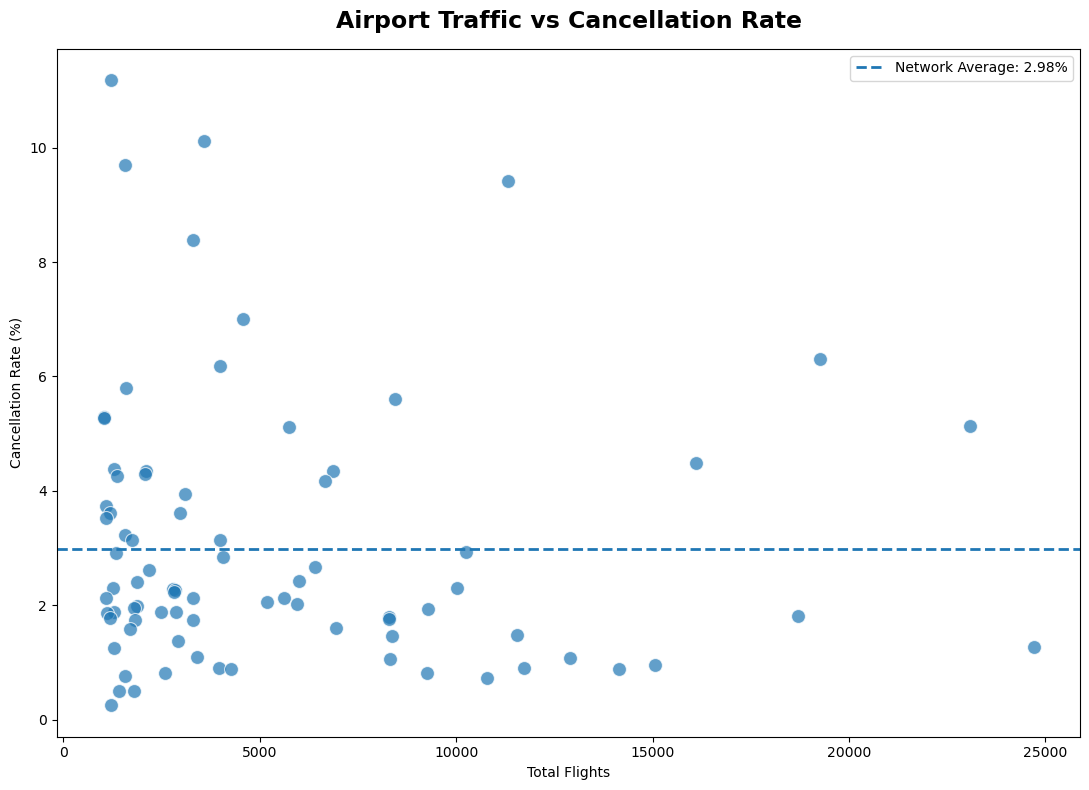

In [50]:
# TRAFFIC VS CANCELLATION CHART
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=airport_reliable_sample,
    x="Total_Flights",
    y="Cancellation_Rate",
    s=100,
    alpha=0.7
)

plt.axhline(
    overall_cancellation_rate,
    linestyle="--",
    linewidth=2,
    label=f"Network Average: {overall_cancellation_rate:.2f}%"
)

plt.title(
    "Airport Traffic vs Cancellation Rate",
    fontsize=17,
    fontweight="bold",
    pad=15
)

plt.xlabel("Total Flights")
plt.ylabel("Cancellation Rate (%)")

plt.legend()

plt.tight_layout()
plt.show()

# BUSSINESS INSIGHT
###  Key Finding
Among airports with at least **1,000 flight records**, **[SAV]** recorded the highest cancellation rate at **[11.18]%**.

The overall network cancellation rate was **[2.98]%**.


# INSIGHT 5 — Airport Traffic vs Delay Rate
-  Which airports handle a lot of traffic while also having unusually high delay rates


In [51]:
# AIRPORT TOTAL TRAFFIC
airport_flights=df.groupby('Origin').size().reset_index(name='Total_Flights')
display(airport_flights)

,Origin,Total_Flights
0,ABE,135
1,ABQ,1705
2,ABR,61
3,ABY,74
4,ACT,93
...,...,...
313,WRG,60
314,XNA,424
315,XWA,178
316,YAK,60


In [52]:
# DELAYED FILGHTS
airport_delays=df.groupby('Origin')['IsDelayed15'].sum().reset_index(name="Delayed_15_Flights")
display(airport_delays)

,Origin,Delayed_15_Flights
0,ABE,17
1,ABQ,203
2,ABR,8
3,ABY,13
4,ACT,22
...,...,...
313,WRG,7
314,XNA,93
315,XWA,64
316,YAK,5


In [53]:
# MERGING BOTH ON ORIGIN
airport_delay_analysis=airport_flights.merge(
    airport_delays,
    on='Origin'
)
display(airport_delay_analysis)

,Origin,Total_Flights,Delayed_15_Flights
0,ABE,135,17
1,ABQ,1705,203
2,ABR,61,8
3,ABY,74,13
4,ACT,93,22
...,...,...,...
313,WRG,60,7
314,XNA,424,93
315,XWA,178,64
316,YAK,60,5


In [54]:
# DELAY RATE
airport_delay_analysis["Delay_Rate"] = (
    airport_delay_analysis["Delayed_15_Flights"]
    / airport_delay_analysis["Total_Flights"]
    * 100
).round(2)
display(airport_delay_analysis)

,Origin,Total_Flights,Delayed_15_Flights,Delay_Rate
0,ABE,135,17,12.59
1,ABQ,1705,203,11.91
2,ABR,61,8,13.11
3,ABY,74,13,17.57
4,ACT,93,22,23.66
...,...,...,...,...
313,WRG,60,7,11.67
314,XNA,424,93,21.93
315,XWA,178,64,35.96
316,YAK,60,5,8.33


In [55]:
# NETWORK BENCHMARK 
overall_delay_rate = df["IsDelayed15"].mean() * 100

print(f"Network Delay Rate: {overall_delay_rate:.2f}%")

Network Delay Rate: 18.23%


In [56]:
airport_delay_analysis["vs_Overall"] = (
    airport_delay_analysis["Delay_Rate"]
    - overall_delay_rate
).round(2)

In [57]:
# FOR MIN 1000 FLIGHTS
minimum_flights = 1000

airport_reliable_sample = (
    airport_delay_analysis[
        airport_delay_analysis["Total_Flights"] >= minimum_flights
    ]
    .copy()
)

In [58]:
# WORST PERFORMING
airport_delay_ranking = (
    airport_reliable_sample
    .sort_values("Delay_Rate", ascending=False)
)

airport_delay_ranking.head(15)

,Origin,Total_Flights,Delayed_15_Flights,Delay_Rate,vs_Overall
14,ASE,1025,325,31.71,13.48
278,SJU,2909,763,26.23,8.00
120,GRR,1121,283,25.25,7.02
79,DEN,24701,6061,24.54,6.31
85,DTW,8362,2025,24.22,5.99
46,BUF,1341,322,24.01,5.78
223,PHL,6405,1524,23.79,5.56
229,PIT,2802,663,23.66,5.43
60,CLE,2819,658,23.34,5.11
192,MIA,8296,1884,22.71,4.48


In [59]:
# TOP 15
top_15_delay_airports = (
    airport_delay_ranking
    .head(15)
    .sort_values("Delay_Rate", ascending=True)
)

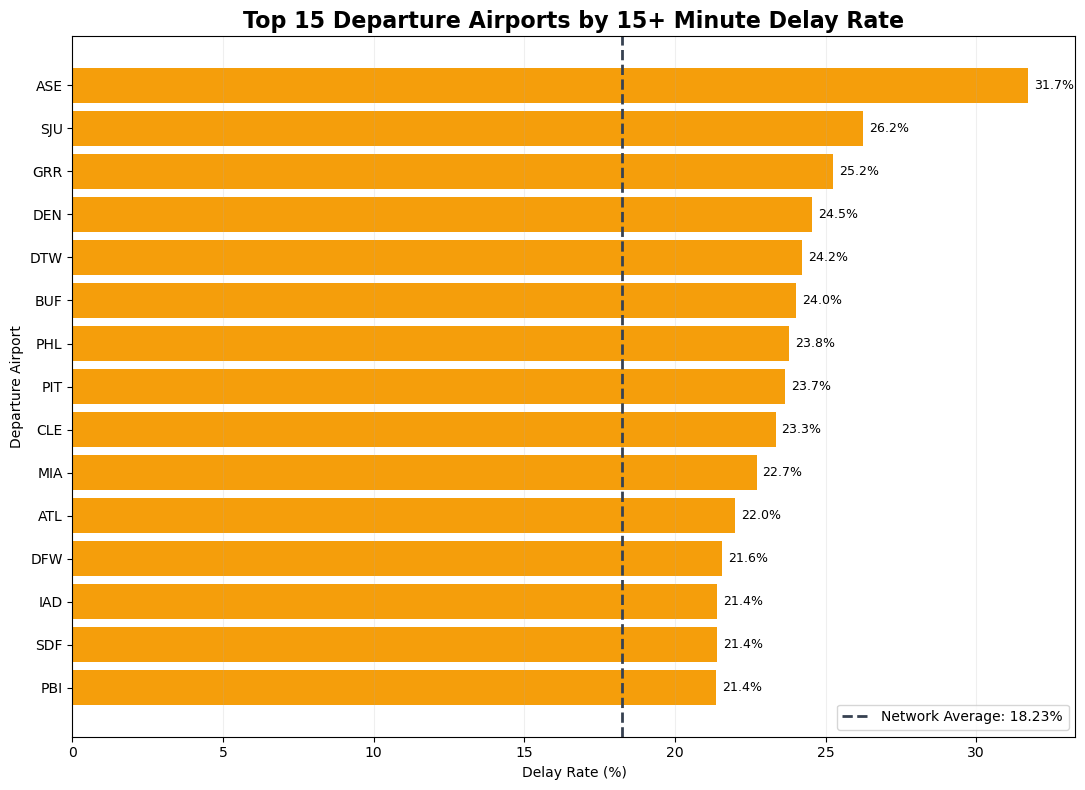

In [60]:
# VISUALIZATION
plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_15_delay_airports["Origin"],
    top_15_delay_airports["Delay_Rate"],
    color="#F59E0B"
)

plt.axvline(
    overall_delay_rate,
    color="#374151",
    linestyle="--",
    linewidth=2,
    label=f"Network Average: {overall_delay_rate:.2f}%"
)

plt.title(
    "Top 15 Departure Airports by 15+ Minute Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Departure Airport")

plt.legend()
plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [61]:
# MEDIAN TRAFIC AND DELAY RATE
traffic_threshold = airport_reliable_sample["Total_Flights"].median()
delay_threshold = airport_reliable_sample["Delay_Rate"].median()

print(f"Traffic Threshold: {traffic_threshold:,.0f} flights")
print(f"Delay Threshold: {delay_threshold:.2f}%")

Traffic Threshold: 3,301 flights
Delay Threshold: 16.35%


In [62]:
# AIRPORT SEGMENT
airport_reliable_sample["Airport_Segment"] = np.select(
    [
        (
            (airport_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] >= delay_threshold)
        ),
        (
            (airport_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] < delay_threshold)
        ),
        (
            (airport_reliable_sample["Total_Flights"] < traffic_threshold) &
            (airport_reliable_sample["Delay_Rate"] >= delay_threshold)
        )
    ],
    [
        "High Traffic / High Delay",
        "High Traffic / Low Delay",
        "Low Traffic / High Delay"
    ],
    default="Low Traffic / Low Delay"
)

segment_counts = (
    airport_reliable_sample["Airport_Segment"]
    .value_counts()
)

display(segment_counts)

Airport_Segment
High Traffic / High Delay    23
Low Traffic / Low Delay      22
Low Traffic / High Delay     18
High Traffic / Low Delay     18
Name: count, dtype: int64

In [63]:
# HIGH TRAFFIC 
high_risk_airports = (
    airport_reliable_sample[
        airport_reliable_sample["Airport_Segment"] ==
        "High Traffic / High Delay"
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

high_risk_airports[
    ["Origin", "Total_Flights", "Delay_Rate", "vs_Overall"]
].head(15)

,Origin,Total_Flights,Delay_Rate,vs_Overall
79,DEN,24701,24.54,6.31
85,DTW,8362,24.22,5.99
223,PHL,6405,23.79,5.56
192,MIA,8296,22.71,4.48
15,ATL,23096,21.99,3.76
80,DFW,19275,21.56,3.33
138,IAD,3994,21.41,3.18
76,DCA,11329,21.09,2.86
105,FLL,5605,20.96,2.73
213,ORD,18702,20.55,2.32


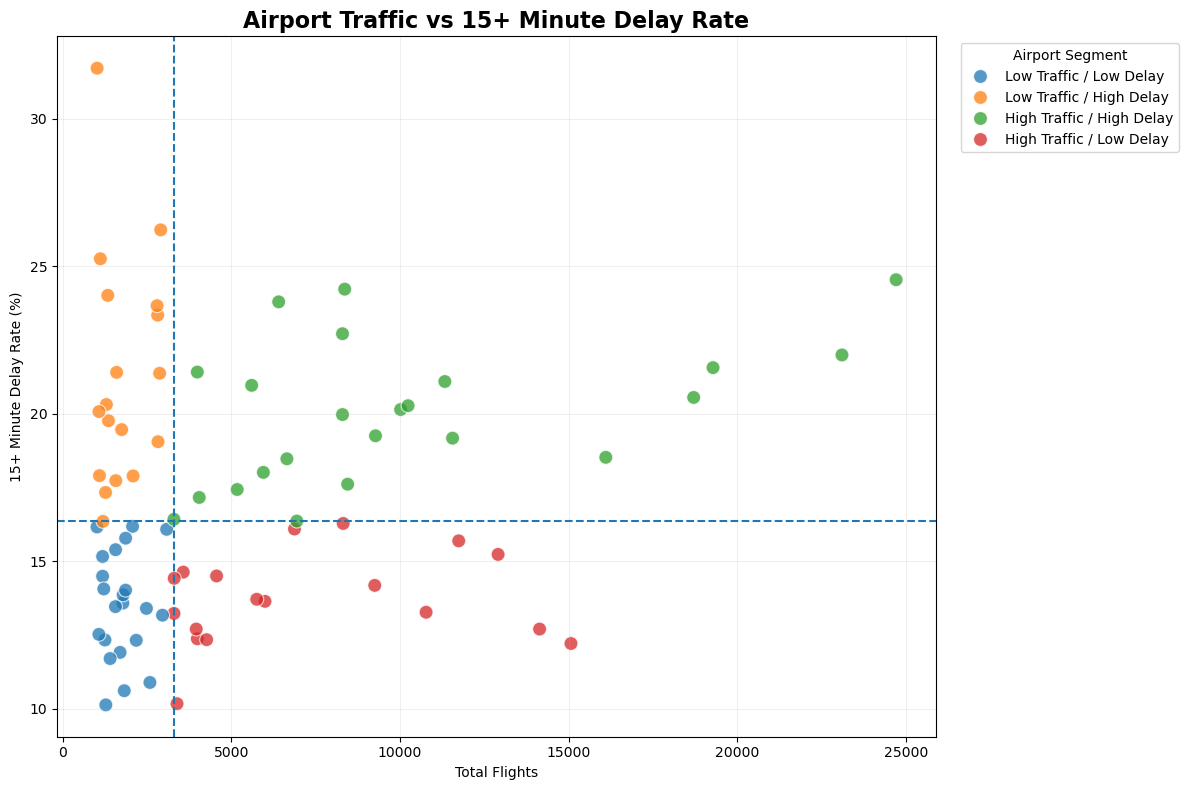

In [64]:
#HIGH TRAFFIC VISUALIZATION
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=airport_reliable_sample,
    x="Total_Flights",
    y="Delay_Rate",
    hue="Airport_Segment",
    s=100,
    alpha=0.75
)

plt.axvline(
    traffic_threshold,
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    delay_threshold,
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Airport Traffic vs 15+ Minute Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Flights")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.legend(
    title="Airport Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# BUSSINESS INSIGHT
###  Key Finding
Airline **[ASE]** has the highest 15+ minute delay rate at **[31.7%]%**.


# INSIGHT 6 — Busiest Departure Airports
-  Which airports handle the largest number of departing flights

In [65]:
# TOTAL FLIGHTS BY ORIGIN
display(airport_flights)

,Origin,Total_Flights
0,ABE,135
1,ABQ,1705
2,ABR,61
3,ABY,74
4,ACT,93
...,...,...
313,WRG,60
314,XNA,424
315,XWA,178
316,YAK,60


In [66]:
busiest_airports = (
    airport_flights
    .sort_values("Total_Flights", ascending=False)
)

busiest_airports.head(15)

,Origin,Total_Flights
79,DEN,24701
15,ATL,23096
80,DFW,19275
213,ORD,18702
62,CLT,16098
224,PHX,15066
163,LAX,14136
161,LAS,12906
268,SEA,11740
181,MCO,11558


In [67]:
total_network_flights = len(df)

busiest_airports["Traffic_Share"] = (
    busiest_airports["Total_Flights"]
    / total_network_flights
    * 100
).round(2)
busiest_airports.head(15)

,Origin,Total_Flights,Traffic_Share
79,DEN,24701,5.07
15,ATL,23096,4.74
80,DFW,19275,3.96
213,ORD,18702,3.84
62,CLT,16098,3.30
224,PHX,15066,3.09
163,LAX,14136,2.90
161,LAS,12906,2.65
268,SEA,11740,2.41
181,MCO,11558,2.37


In [68]:
# TOP 15 Busiest Airport
top_15_busiest = (
    busiest_airports
    .head(15)
    .sort_values("Total_Flights", ascending=True)
)

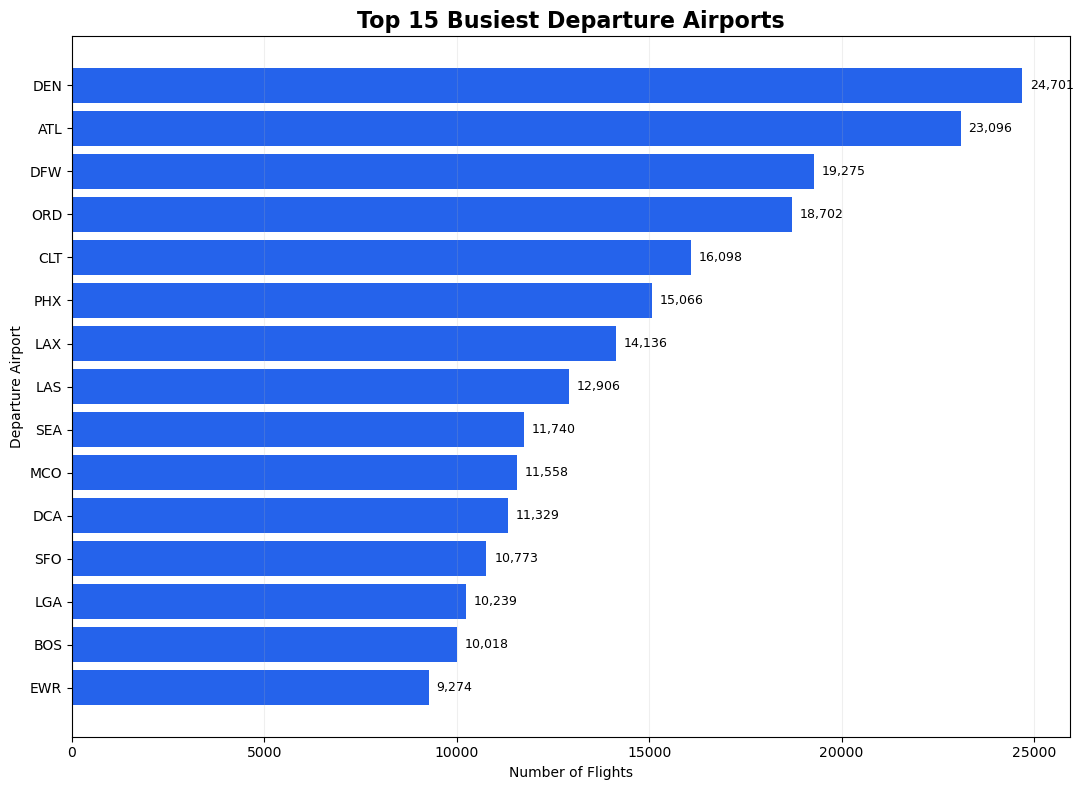

In [69]:
plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_15_busiest["Origin"],
    top_15_busiest["Total_Flights"],
    color="#2563EB"
)

plt.title(
    "Top 15 Busiest Departure Airports",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Flights")
plt.ylabel("Departure Airport")

plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [70]:
busiest_airports["Cumulative_Share"] = (
    busiest_airports["Traffic_Share"].cumsum()
)
busiest_airports.head(15)[
    ["Origin", "Total_Flights", "Traffic_Share", "Cumulative_Share"]
]

,Origin,Total_Flights,Traffic_Share,Cumulative_Share
79,DEN,24701,5.07,5.07
15,ATL,23096,4.74,9.81
80,DFW,19275,3.96,13.77
213,ORD,18702,3.84,17.61
62,CLT,16098,3.30,20.91
224,PHX,15066,3.09,24.00
163,LAX,14136,2.90,26.90
161,LAS,12906,2.65,29.55
268,SEA,11740,2.41,31.96
181,MCO,11558,2.37,34.33


In [71]:
top_10_share = (
    busiest_airports
    .head(10)["Traffic_Share"]
    .sum()
)

print(f"Top 10 airports traffic share: {top_10_share:.2f}%")

Top 10 airports traffic share: 34.33%


In [72]:
airport_volume_delay = busiest_airports.merge(
    airport_reliable_sample[
        ["Origin", "Delay_Rate", "vs_Overall"]
    ],
    on="Origin",
    how="left"
)

In [73]:
# TOP 15 BUSIEST 
top_15_volume_delay = (
    airport_volume_delay
    .head(15)
    .sort_values("Total_Flights", ascending=False)
)

top_15_volume_delay[
    [
        "Origin",
        "Total_Flights",
        "Traffic_Share",
        "Delay_Rate",
        "vs_Overall"
    ]
]

,Origin,Total_Flights,Traffic_Share,Delay_Rate,vs_Overall
0,DEN,24701,5.07,24.54,6.31
1,ATL,23096,4.74,21.99,3.76
2,DFW,19275,3.96,21.56,3.33
3,ORD,18702,3.84,20.55,2.32
4,CLT,16098,3.30,18.52,0.29
5,PHX,15066,3.09,12.21,-6.02
6,LAX,14136,2.90,12.70,-5.53
7,LAS,12906,2.65,15.23,-3.00
8,SEA,11740,2.41,15.69,-2.54
9,MCO,11558,2.37,19.17,0.94


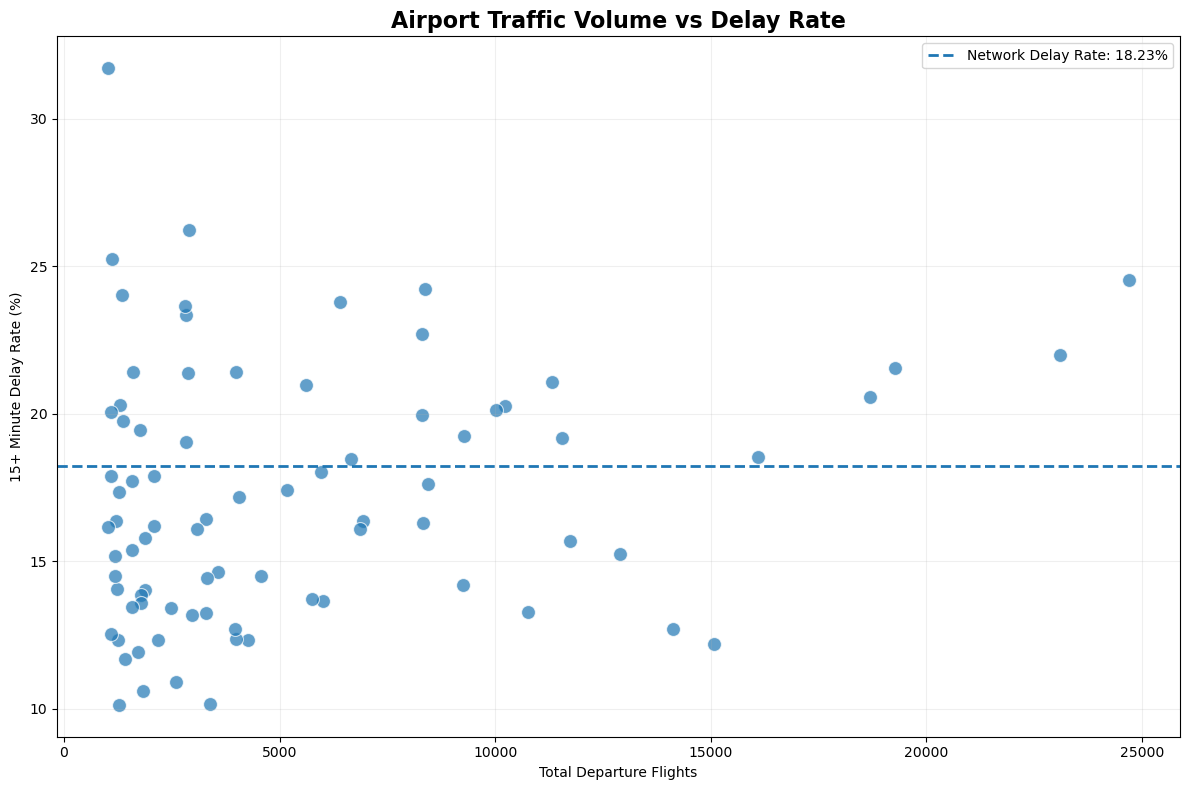

In [74]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=airport_volume_delay,
    x="Total_Flights",
    y="Delay_Rate",
    s=100,
    alpha=0.7
)

plt.axhline(
    overall_delay_rate,
    linestyle="--",
    linewidth=2,
    label=f"Network Delay Rate: {overall_delay_rate:.2f}%"
)

plt.title(
    "Airport Traffic Volume vs Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Departure Flights")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# INSIGHT 7 — Busiest Destination Airports
-  Which destination airports receive the largest number of flights

In [75]:
destination_flights = (
    df.groupby("Dest")
      .size()
      .reset_index(name="Total_Arriving_Flights")
)

destination_flights.head()

,Dest,Total_Arriving_Flights
0,ABE,135
1,ABQ,1705
2,ABR,61
3,ABY,75
4,ACT,93


In [76]:
# RANKING AIRPORTS
busiest_destinations = (
    destination_flights
    .sort_values(
        "Total_Arriving_Flights",
        ascending=False
    )
)

busiest_destinations.head(15)

,Dest,Total_Arriving_Flights
79,DEN,24710
15,ATL,23089
80,DFW,19277
213,ORD,18698
62,CLT,16103
224,PHX,15061
163,LAX,14126
161,LAS,12888
268,SEA,11751
181,MCO,11553


In [77]:
total_network_flights = len(df)

busiest_destinations["Traffic_Share"] = (
    busiest_destinations["Total_Arriving_Flights"]
    / total_network_flights
    * 100
).round(2)

In [78]:
# TOP 15 DESTINATION
top_15_destinations = (
    busiest_destinations
    .head(15)
    .sort_values(
        "Total_Arriving_Flights",
        ascending=True
    )
)

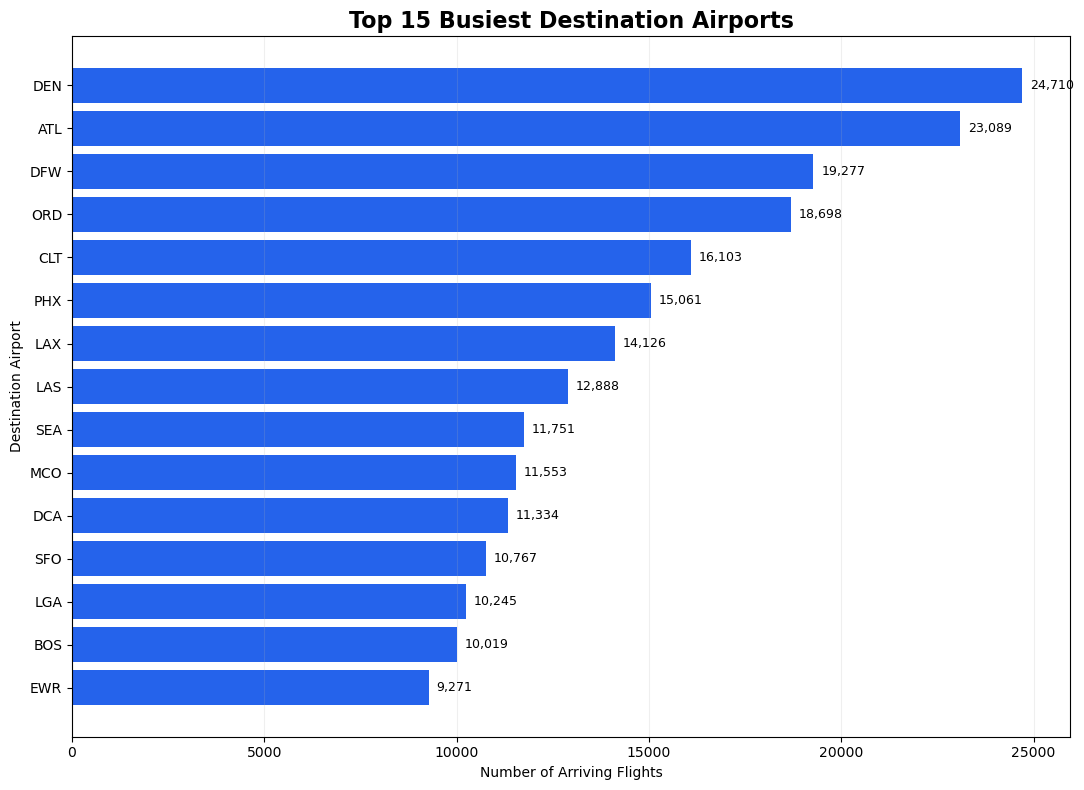

In [79]:
plt.figure(figsize=(11, 8))

bars = plt.barh(
    top_15_destinations["Dest"],
    top_15_destinations["Total_Arriving_Flights"],
    color="#2563EB"
)

plt.title(
    "Top 15 Busiest Destination Airports",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Arriving Flights")
plt.ylabel("Destination Airport")

plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 200,
        bar.get_y() + bar.get_height() / 2,
        f"{width:,.0f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [80]:
# NETWORK FLOW
airport_network_flow = airport_flights.merge(
    destination_flights,
    left_on="Origin",
    right_on="Dest",
    how="outer"
)

airport_network_flow.head()

airport_network_flow = (
    airport_network_flow
    .rename(columns={"Origin": "Airport"})
    .drop(columns=["Dest"])
)

airport_network_flow.head()

,Airport,Total_Flights,Total_Arriving_Flights
0,ABE,135,135
1,ABQ,1705,1705
2,ABR,61,61
3,ABY,74,75
4,ACT,93,93


In [81]:
# FLOW COMPARISON
airport_network_flow["Flow_Difference"] = (
    airport_network_flow["Total_Arriving_Flights"]
    - airport_network_flow["Total_Flights"]
)

In [82]:
airport_network_flow.sort_values(
    "Flow_Difference",
    ascending=True
).head(10)

,Airport,Total_Flights,Total_Arriving_Flights,Flow_Difference
120,GRR,1121,1099,-22
161,LAS,12906,12888,-18
183,MDT,265,248,-17
16,ATW,402,391,-11
20,AZA,166,156,-10
192,MIA,8296,8286,-10
163,LAX,14136,14126,-10
278,SJU,2909,2900,-9
33,BLV,23,14,-9
222,PGD,203,196,-7


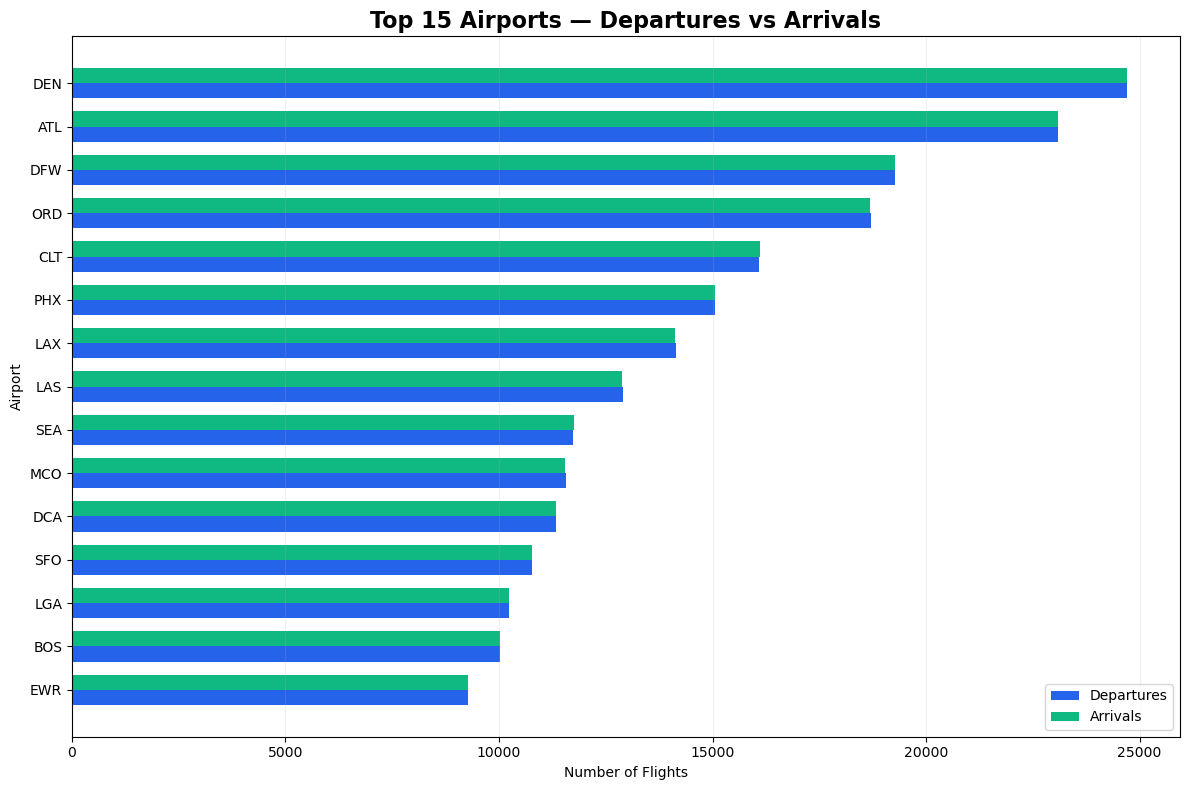

In [83]:
# Top 15 airports by total network activity
top_15_flow = (
    airport_network_flow
    .assign(
        Total_Activity=lambda x:
        x["Total_Flights"] + x["Total_Arriving_Flights"]
    )
    .sort_values("Total_Activity", ascending=False)
    .head(15)
    .sort_values("Total_Activity", ascending=True)
)

plt.figure(figsize=(12, 8))

y = np.arange(len(top_15_flow))
height = 0.35

plt.barh(
    y - height/2,
    top_15_flow["Total_Flights"],
    height,
    label="Departures",
    color="#2563EB"
)

plt.barh(
    y + height/2,
    top_15_flow["Total_Arriving_Flights"],
    height,
    label="Arrivals",
    color="#10B981"
)

plt.yticks(
    y,
    top_15_flow["Airport"]
)

plt.xlabel("Number of Flights")
plt.ylabel("Airport")

plt.title(
    "Top 15 Airports — Departures vs Arrivals",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

# BUSINESS INSIGHT
“Destination traffic analysis shows where the aviation network is most concentrated on the arrival side. Comparing arrival and departure volumes provides an additional view of airport network flow and highlights airports where traffic is relatively more inbound or outbound

# INSIGHT 7 — Route-Level Flight Volume
-  Which destination airports receive the largest number of flights


In [84]:
route_flights = (
    df.groupby("Route")
      .size()
      .reset_index(name="Total_Flights")
      .sort_values("Total_Flights", ascending=False)
)

route_flights.head(15)

,Route,Total_Flights
3706,ORD → LGA,865
2870,LGA → ORD,861
2783,LAX → SFO,852
4801,SFO → LAX,849
4006,PHX → DEN,793
1374,DEN → PHX,787
2747,LAX → JFK,775
2520,JFK → LAX,772
556,BOS → DCA,754
1170,DCA → BOS,752


In [85]:
# TRAFFIC SHARE
total_network_flights = len(df)

route_flights["Traffic_Share"] = (
    route_flights["Total_Flights"]
    / total_network_flights
    * 100
).round(2)

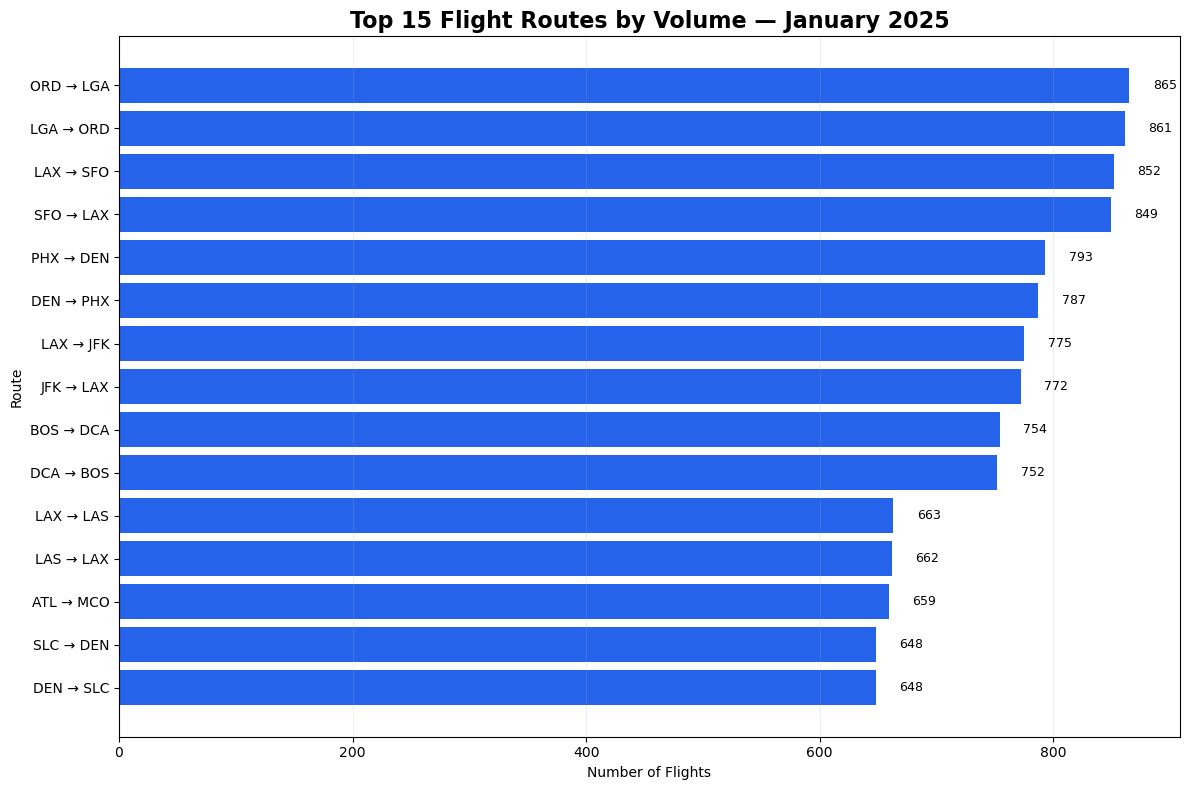

In [86]:
top_15_routes = (
    route_flights
    .head(15)
    .sort_values("Total_Flights", ascending=True)
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_15_routes["Route"],
    top_15_routes["Total_Flights"],
    color="#2563EB"
)

plt.xlabel("Number of Flights")
plt.ylabel("Route")

plt.title(
    "Top 15 Flight Routes by Volume — January 2025",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.2)

# Add data labels
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# INSIGHT 9 — Route Delay Performance
-  Which routes have the highest 15+ minute delay rates

In [87]:
# TOTAL ROUTE FLIGHTS
route_flights = (
    df.groupby("Route")
      .size()
      .reset_index(name="Total_Flights")
)

In [88]:
# DELAY BY ROUTES
route_delays = (
    df.groupby("Route")["IsDelayed15"]
      .sum()
      .reset_index(name="Delayed_15_Flights")
)
# COMBINE
route_delay_analysis = route_flights.merge(
    route_delays,
    on="Route"
)

In [89]:
route_delay_analysis["Delay_Rate"] = (
    route_delay_analysis["Delayed_15_Flights"]
    / route_delay_analysis["Total_Flights"]
    * 100
).round(2)
display(route_delay_analysis)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
0,ABE → BNA,1,0,0.00
1,ABE → CLT,93,14,15.05
2,ABE → FLL,2,1,50.00
3,ABE → MCO,1,0,0.00
4,ABE → MLB,7,1,14.29
...,...,...,...,...
5429,XWA → MSP,67,25,37.31
5430,YAK → CDV,30,4,13.33
5431,YAK → JNU,30,1,3.33
5432,YUM → DFW,31,4,12.90


In [90]:
# FOR MIn 1000 flights
minimum_flights = 100

route_reliable_sample = (
    route_delay_analysis[
        route_delay_analysis["Total_Flights"] >= minimum_flights
    ]
    .copy()
)

In [91]:
# RANK ROUTES
route_delay_ranking = (
    route_reliable_sample
    .sort_values("Delay_Rate", ascending=False)
)

route_delay_ranking.head(15)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate
2217,HSV → DCA,101,45,44.55
3636,ORD → ASE,143,63,44.06
1348,DEN → MAF,119,50,42.02
582,BOS → PBI,238,99,41.60
590,BOS → RSW,204,83,40.69
1198,DCA → HSV,100,40,40.00
603,BOS → TPA,212,83,39.15
1270,DEN → BIS,124,48,38.71
636,BUF → DCA,114,44,38.60
428,BIS → DEN,124,47,37.90


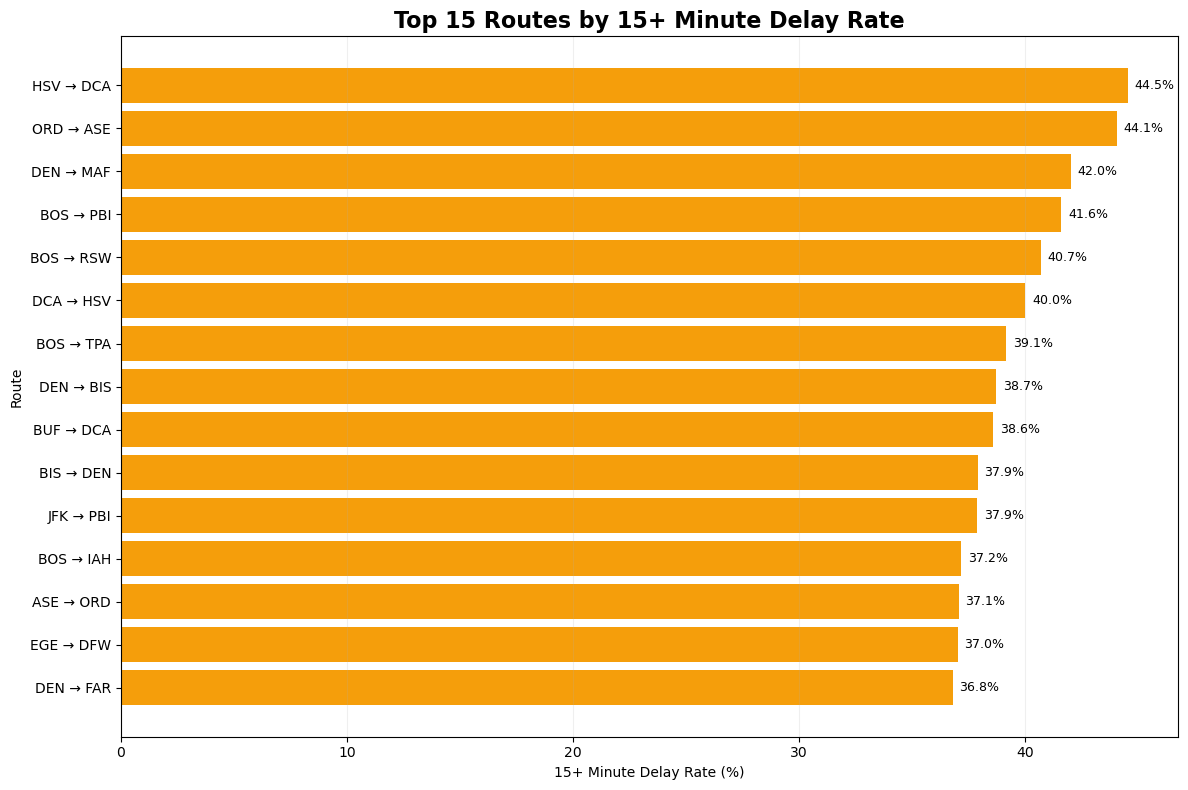

In [92]:
top_15_delayed_routes = (
    route_delay_ranking
    .head(15)
    .sort_values("Delay_Rate", ascending=True)
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_15_delayed_routes["Route"],
    top_15_delayed_routes["Delay_Rate"],
    color="#F59E0B"
)

plt.xlabel("15+ Minute Delay Rate (%)")
plt.ylabel("Route")

plt.title(
    "Top 15 Routes by 15+ Minute Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.2)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# INSIGHT 10 — Route Volume vs Delay Rate
-  Which routes have both high traffic and high delay rates
-  Traffic volume → how important the route is
-  Delay rate → how reliable the route is

In [93]:
traffic_threshold = route_reliable_sample["Total_Flights"].median()
delay_threshold = route_reliable_sample["Delay_Rate"].median()

print(f"Traffic threshold: {traffic_threshold:,.0f} flights")
print(f"Delay threshold: {delay_threshold:.2f}%")

Traffic threshold: 176 flights
Delay threshold: 17.31%


In [95]:
# ROUTE WISE SEGMENT
route_reliable_sample["Route_Segment"] = np.select(
    [
        (
            (route_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (route_reliable_sample["Delay_Rate"] >= delay_threshold)
        ),
        (
            (route_reliable_sample["Total_Flights"] >= traffic_threshold) &
            (route_reliable_sample["Delay_Rate"] < delay_threshold)
        ),
        (
            (route_reliable_sample["Total_Flights"] < traffic_threshold) &
            (route_reliable_sample["Delay_Rate"] >= delay_threshold)
        )
    ],
    [
        "High Traffic / High Delay",
        "High Traffic / Low Delay",
        "Low Traffic / High Delay"
    ],
    default="Low Traffic / Low Delay"
)
route_reliable_sample["Route_Segment"].value_counts()

Route_Segment
High Traffic / High Delay    414
Low Traffic / Low Delay      408
High Traffic / Low Delay     396
Low Traffic / High Delay     390
Name: count, dtype: int64

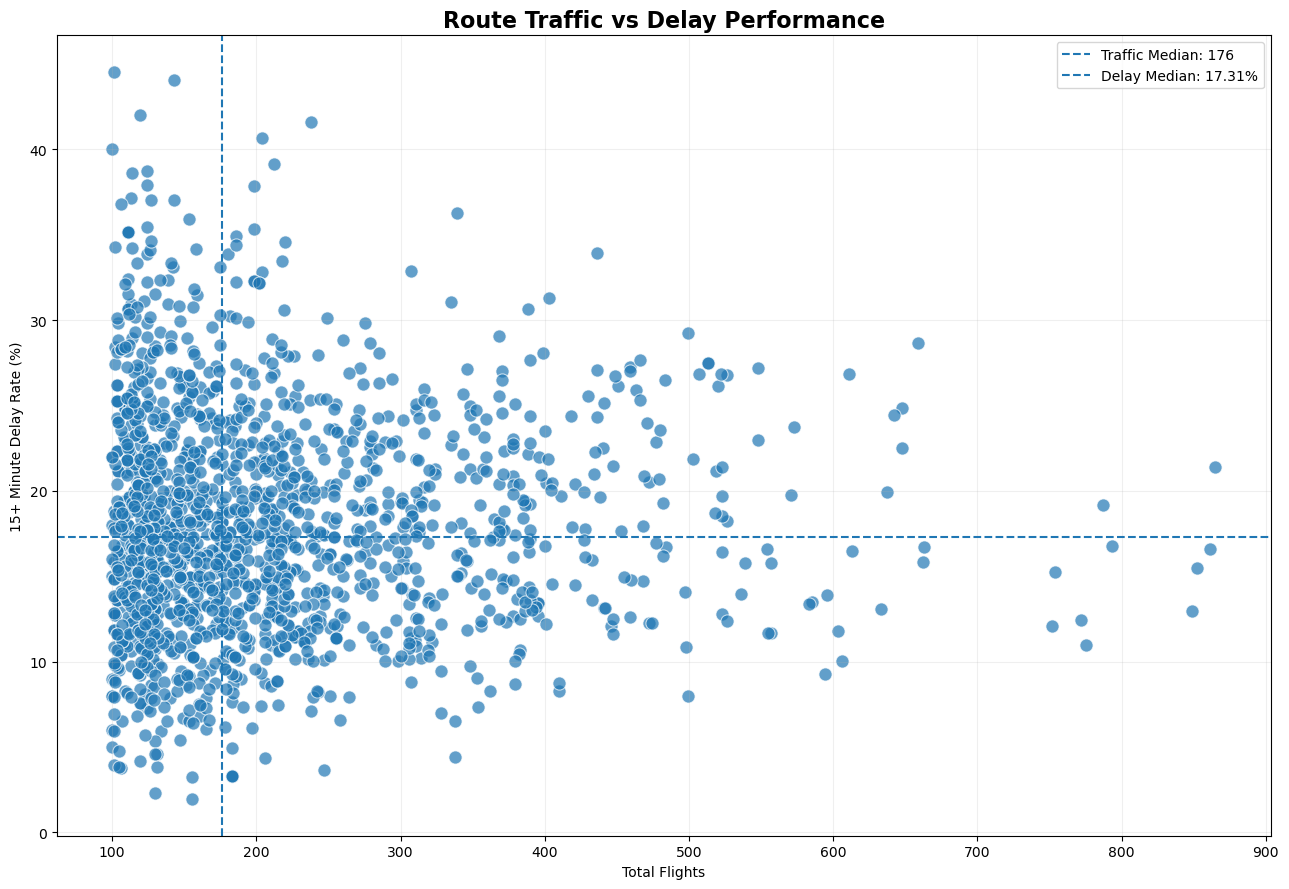

In [96]:
# VISUALIZATION
plt.figure(figsize=(13, 9))

sns.scatterplot(
    data=route_reliable_sample,
    x="Total_Flights",
    y="Delay_Rate",
    s=90,
    alpha=0.7
)

plt.axvline(
    traffic_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Traffic Median: {traffic_threshold:,.0f}"
)

plt.axhline(
    delay_threshold,
    linestyle="--",
    linewidth=1.5,
    label=f"Delay Median: {delay_threshold:.2f}%"
)

plt.xlabel("Total Flights")
plt.ylabel("15+ Minute Delay Rate (%)")

plt.title(
    "Route Traffic vs Delay Performance",
    fontsize=16,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [97]:
# TOP PRIORITY ROUTES
high_priority_routes = (
    route_reliable_sample[
        route_reliable_sample["Route_Segment"] ==
        "High Traffic / High Delay"
    ]
    .sort_values(
        ["Delay_Rate", "Total_Flights"],
        ascending=[False, False]
    )
)

high_priority_routes.head(15)

,Route,Total_Flights,Delayed_15_Flights,Delay_Rate,Route_Segment
582,BOS → PBI,238,99,41.60,High Traffic / High Delay
590,BOS → RSW,204,83,40.69,High Traffic / High Delay
603,BOS → TPA,212,83,39.15,High Traffic / High Delay
2530,JFK → PBI,198,75,37.88,High Traffic / High Delay
574,BOS → MCO,339,123,36.28,High Traffic / High Delay
1647,DTW → MCO,198,70,35.35,High Traffic / High Delay
1033,CPR → DEN,186,65,34.95,High Traffic / High Delay
562,BOS → FLL,220,76,34.55,High Traffic / High Delay
1295,DEN → DRO,186,64,34.41,High Traffic / High Delay
1285,DEN → COS,436,148,33.94,High Traffic / High Delay
